In [1]:
import numpy as np
import torch
import os
from matplotlib import pyplot as plt

from place_cells import PlaceCells
from trajectory_generator import TrajectoryGenerator

from model import *
from visualize import compute_grid_scores
import argparse
from tqdm import tqdm
from sklearn.decomposition import PCA, NMF, SparsePCA

In [104]:
# Training options and hyperparameters
class Options:
    pass
options = Options()

# options.save_dir = '/mnt/fs2/bsorsch/grid_cells/models/'
options.batch_size = 5000      # number of trajectories per batch
options.sequence_length = 10  # number of steps in trajectory
options.Np = 512              # number of place cells
options.Ng = 64           # number of grid cells
options.place_cell_rf = 0.12  # width of place cell center tuning curve (m)
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.DoG = False  # use difference of gaussians tuning curves
options.periodic = False    # trajectories with periodic boundary conditions
options.box_width = 1.4    # width of training environment
options.box_height = 1.4      # height of training environment
options.device = 'cuda'     # specify devices
options.normalize_pc = 'softmax'
options.dt = 0.02
options.res = 30

In [105]:
place_cells = PlaceCells(options)
trajectory_generator = TrajectoryGenerator(options, place_cells)

pos = np.array(
    np.meshgrid(
        np.linspace(-options.box_width/2, options.box_width/2, options.res),
        np.linspace(-options.box_height/2, options.box_height/2, options.res)
    )
).T
pos = torch.tensor(pos).to(options.device)

# get place cell activations
pc_outputs = place_cells.get_activation(pos).detach().cpu()
pc_outputs = pc_outputs.reshape(options.res ** 2, options.Np)
pc_outputs_np = pc_outputs.cpu().numpy() # Nx x Np

## PCA

  0%|          | 0/64 [00:00<?, ?it/s]c:\Projects\place-cell-exploration\scores.py:131: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\Projects\place-cell-exploration\scores.py:138: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
100%|██████████| 64/64 [00:01<00:00, 33.33it/s]


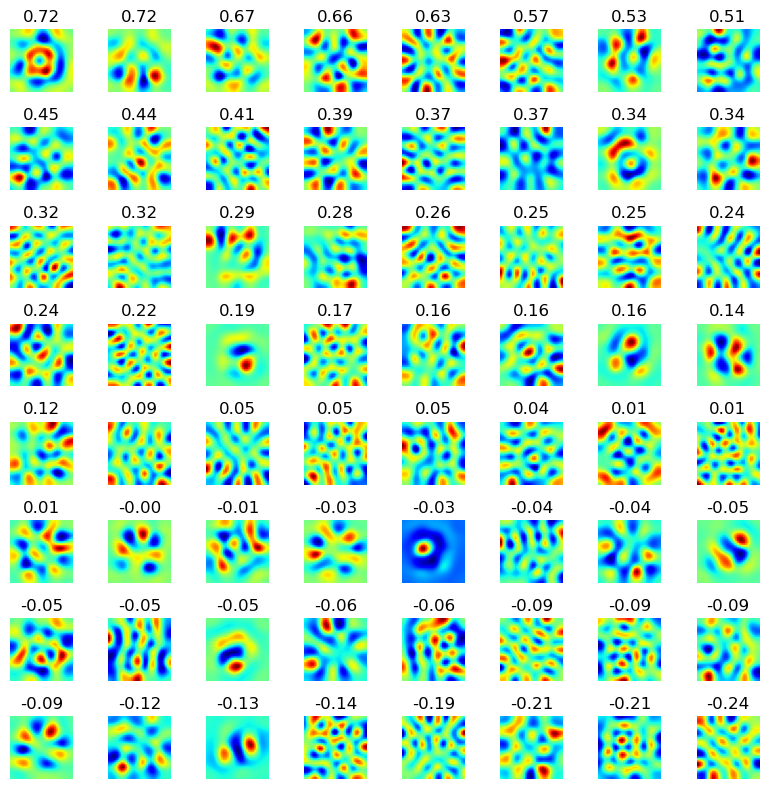

In [94]:
# PCA
pca = PCA(n_components=options.Ng) 
principal_comps = pca.fit_transform(pc_outputs_np) 

gcs = principal_comps.T.reshape((-1, options.res, options.res))
idx, scores = compute_grid_scores(options.res, gcs, options)
sorted_gcs = gcs[idx]

n = int(np.sqrt(options.Ng))
fig, axes = plt.subplots(n, n, figsize=(n, n))
for i, ax in enumerate(axes.flatten()):
    gc = (sorted_gcs[i] - np.min(sorted_gcs[i])) / (np.max(sorted_gcs[i]) - np.min(sorted_gcs[i]))
    ax.imshow(gc, cmap='jet')
    ax.set_title(f'{scores[i]:.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## NMF

c:\Users\mufen\miniconda3\envs\dlenv\lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/64 [00:00<?, ?it/s]c:\Projects\place-cell-exploration\scores.py:131: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\Projects\place-cell-exploration\scores.py:138: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
100%|██████████| 64/64 [00:03<00:00, 19.88it/s]


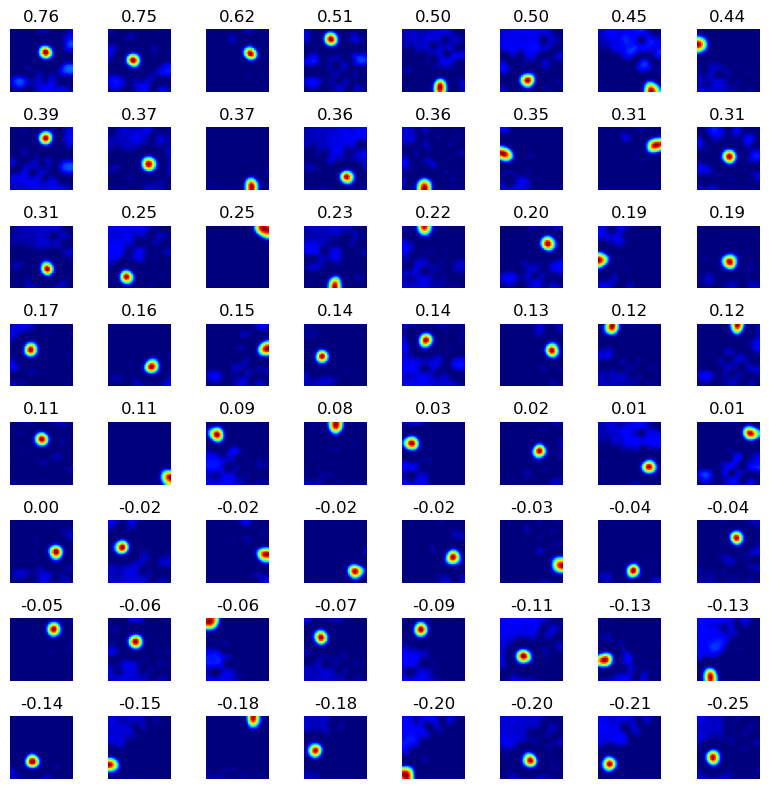

In [12]:
# NMF
nmf = NMF(n_components=options.Ng, max_iter=1000, tol=1e-6, verbose=0)
W = nmf.fit_transform(pc_outputs_np)

gcs = W.T.reshape((-1, options.res, options.res))
idx, scores = compute_grid_scores(options.res, gcs, options)
sorted_gcs = gcs[idx]

n = int(np.sqrt(options.Ng))
fig, axes = plt.subplots(n, n, figsize=(n, n))
for i, ax in enumerate(axes.flatten()):
    gc = (sorted_gcs[i] - np.min(sorted_gcs[i])) / (np.max(sorted_gcs[i]) - np.min(sorted_gcs[i]))
    ax.imshow(gc, cmap='jet')
    ax.set_title(f'{scores[i]:.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Sanger's rule

In [109]:
def sanger_update(W, x, eta):
    y = np.dot(W, x)  # Calculate the output
    W_delta = eta * (np.outer(y, x) - np.tril(np.outer(y, y)) @ W)
    W += W_delta
    # Normalize the weight vectors
    W = W * (W > 0)  # ReLU
    W /= np.linalg.norm(W, axis=1, keepdims=True)
    return W

P = pc_outputs_np.copy()

# Normalize P to have zero mean across samples
P -= np.mean(P, axis=0)

# Parameters
W = np.random.randn(options.Ng, options.Np)  # Weight matrix W of size k x p
W /= np.linalg.norm(W, axis=1, keepdims=True)  # Normalize the weight vectors
W_old = W.copy()
eta = 1  # Learning rate
epochs = 100  # Number of epochs

# Training
diffs = []
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % 10 == 0:
        eta *= 1
    for x in P:
        W = sanger_update(W, x, eta)
    
    diff = np.linalg.norm(W - W_old)
    if diff < 1e-6:
        break
    W_old = W.copy()
    diffs.append(diff)

100%|██████████| 100/100 [00:33<00:00,  2.98it/s]


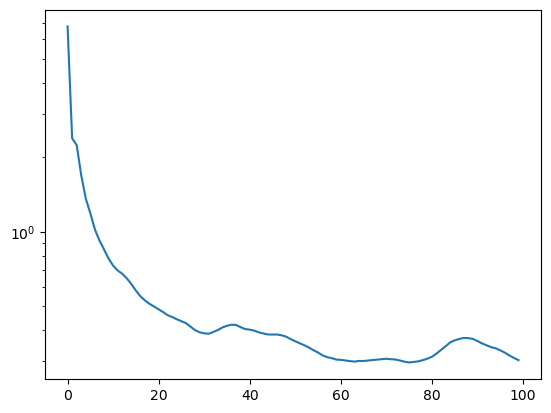

In [110]:
plt.plot(diffs)
plt.yscale('log')

100%|██████████| 64/64 [00:02<00:00, 30.29it/s]


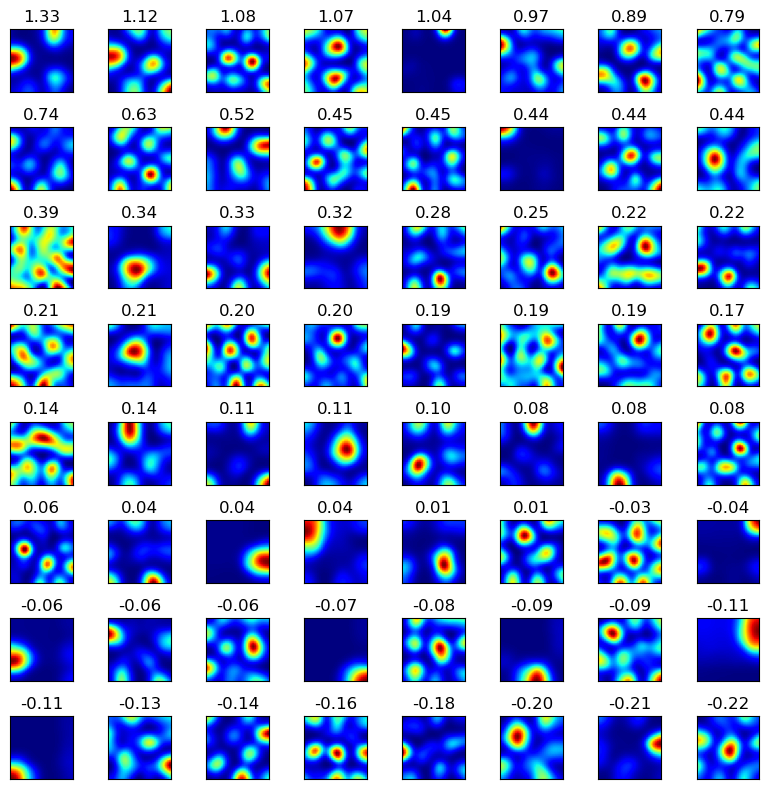

In [112]:
y = np.dot(W, P.T)

gcs = y.reshape((-1, options.res, options.res))
idx, scores = compute_grid_scores(options.res, gcs, options)
sorted_gcs = gcs[idx]

n = int(np.sqrt(options.Ng))
fig, axes = plt.subplots(n, n, figsize=(n, n))
for i, ax in enumerate(axes.flatten()):
    gc = (sorted_gcs[i] - np.min(sorted_gcs[i])) / (np.max(sorted_gcs[i]) - np.min(sorted_gcs[i]))
    ax.imshow(gc, cmap='jet')
    ax.set_title(f'{scores[i]:.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## Oja's rule

In [58]:
def oja_rule(X, eta=0.01, n_epochs=100):
    np.random.seed(0)
    w = np.random.randn(X.shape[1])  # Initialize weights randomly
    w /= np.linalg.norm(w)  # Normalize the initial weights
    w_old = w.copy()

    diffs = []
    for epoch in tqdm(range(n_epochs)):
        for x in X:
            y = np.dot(w, x)  # Calculate the output
            # Update weights according to Oja's rule
            w += eta * (y * x - y**2 * w)
            # w = w * (w > 0)
        # Optionally normalize w at each step
        w[w < 0] = 0
        w /= np.linalg.norm(w)
        # Break if the weights have converged
        diff = np.linalg.norm(w - w_old)
        diffs.append(diff)
        w_old = w.copy()
        if diff < 1e-5:
            break

    return w, diffs

P = pc_outputs_np

# Normalize P to have zero mean across samples
P -= np.mean(P, axis=0)

principal_comps, diffs = oja_rule(P, eta=0.001, n_epochs=100)


100%|██████████| 100/100 [00:00<00:00, 110.23it/s]


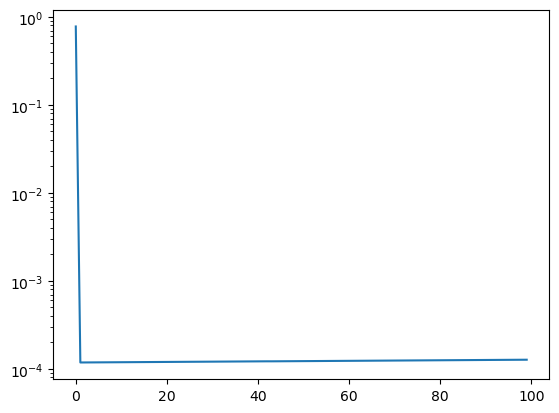

In [59]:
plt.plot(diffs)
plt.yscale('log')

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 36.83it/s]


Text(0.5, 1.0, '0.17')

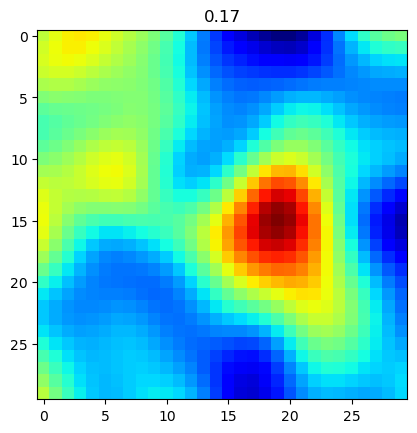

In [60]:
y = np.dot(principal_comps, pc_outputs_np.T)
gc = y.reshape((-1, options.res, options.res))
idx, scores = compute_grid_scores(options.res, gc, options)
plt.imshow(gc[0], cmap='jet')
plt.title(f'{scores[0]:.2f}')

In [41]:
y.shape

(900,)